# Social Media Engagement Analytics

In [1]:
""" The Objective of this Project is to analyze social media engagement data
using Python, Pandas,NumPy, Matplotlib, Seaborn, and Plotly."""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [13]:
# ❖	Task 1 — Data Import & Setup
# 1 -uploading file

from google.colab import files
uploaded = files.upload()

Saving social_media_engagement_5000.csv to social_media_engagement_5000 (2).csv


In [14]:
df = pd.read_csv("social_media_engagement_5000.csv")

In [34]:
# Convert date columns to datetime

df['posted_at'] = pd.to_datetime(df['posted_at'], format='%d-%m-%Y')

In [35]:
df['posted_at'].dtype

dtype('<M8[ns]')

In [36]:
# covert numerical values to appropriate types
count_cols = ['age', 'likes', 'comments', 'shares']
for col in count_cols:
    df[col] = df[col].astype('Int64')

In [37]:
# convert columns to NumPy arrays

likes_arr = df["likes"].to_numpy(dtype=float, na_value=np.nan)
comments_arr = df["comments"].to_numpy(dtype=float, na_value=np.nan)
shares_arr = df["shares"].to_numpy(dtype=float, na_value=np.nan)

In [41]:
# Basic NumPy array Operations

total_interactions = likes_arr + comments_arr + shares_arr
avg_likes = np.nanmean(likes_arr)
max_comments = np.nanmax(comments_arr)

# Results

print("Average Likes:", round(avg_likes,2))
print("Max Comments:", max_comments)
print("First 5 Total Interactions:", total_interactions[:5])

Average Likes: 10107.04
Max Comments: 2999.0
First 5 Total Interactions: [ 8522. 16163.  6161.  7482. 16717.]


In [44]:
# Task 2 - Data Cleaning

# 1 - Detecting Missing Data

print("--- Missing Value Counts ---")
print(df.isnull().sum())

--- Missing Value Counts ---
user_id               0
age                   0
gender                0
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [49]:
# 2 - Handling Missing Values
""" Missing values in numerical columns (age, likes, and comments) were handled using median
imputation because these variables may contain outliers. Missing values in categorical columns
(gender and sentiment) were handled using mode imputation. dropna() was not used because
removing rows would result in unnecessary data loss."""

df["age"] = df["age"].fillna(df["age"].median())
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["likes"] = df["likes"].fillna(df["likes"].median().round())
df["comments"] = df["comments"].fillna(df["comments"].median().round())
df["sentiment"] = df["sentiment"].fillna(df["sentiment"].mode()[0])

In [51]:
#	3 - Identify & remove duplicates

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [53]:
# 4 - Data Formatting

print(df["gender"].value_counts())
print(df[["likes", "comments", "shares"]].describe())

gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64
             likes    comments       shares
count       5000.0      5000.0       4850.0
mean    10107.0124   1502.0398  1002.629485
std    5702.293014  856.393312   579.615158
min           10.0         0.0          0.0
25%         5235.0       792.0        498.0
50%        10106.0      1497.0       1012.0
75%        14959.0     2235.25       1501.0
max        19998.0      2999.0       1999.0


In [57]:
# Feature Cleaning
# - 1 ■	Extract hashtag count

print(df["hashtags"].head(10).to_list())

['#foodie #travel #love', '#fitness', '#foodie', '#music #foodie #fun', '#travel', '#fitness', '#music', '#travel #music #fitness', '#music #fun #fitness', '#lifestyle #love']


In [59]:
df["hashtag_count"] = df["hashtags"].str.split().str.len()
print(df[["hashtags", "hashtag_count"]].head(10))

                  hashtags  hashtag_count
0    #foodie #travel #love              3
1                 #fitness              1
2                  #foodie              1
3      #music #foodie #fun              3
4                  #travel              1
5                 #fitness              1
6                   #music              1
7  #travel #music #fitness              3
8     #music #fun #fitness              3
9         #lifestyle #love              2


In [60]:
# - 2 ■	Clean sentiment labels

print(df["sentiment"].value_counts())

sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64


In [62]:
df["sentiment"] = df["sentiment"].str.strip().str.lower()
print(df["sentiment"].value_counts())

sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64


In [63]:
# ❖	Task 3 — Data Exploration using Pandas

df.head()  # 1st 5 rows

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [64]:
df.tail()   # Last 5 rows

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63,Female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54,Other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [65]:
df.shape  # No of Rows & Columns

(5000, 20)

In [66]:
df.columns  # check column names

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [67]:
df.info() # Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   Int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   Int64         
 8   comments          5000 non-null   Int64         
 9   shares            4850 non-null   Int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [68]:
df.dtypes  # check data Type

,0
user_id,int64
age,Int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,Int64
comments,Int64
shares,Int64


In [69]:
df.describe() # summary of numerical columns

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.0,5000.000000,5000.0,5000.0,4850.0,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.4404,548042.909000,10107.0124,1502.0398,1002.629485,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.0,100068.000000,10.0,0.0,0.0,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.0,322543.500000,5235.0,792.0,498.0,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.0,548077.500000,10106.0,1497.0,1012.0,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.0,771574.500000,14959.0,2235.25,1501.0,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.0,999455.000000,19998.0,2999.0,1999.0,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293014,856.393312,579.615158,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [70]:
# categorical exploration

print("Unique count per categorical column:")
cat_cols = [
    "post_type",
    "post_category",
    "gender",
    "country",
    "device_type",
    "sentiment",
]
for col in cat_cols:
  print(f"{col}: {df[col].nunique()} unique categories")

print("\nUnique post types:", df["post_type"].unique())
print("\nDevice type distribution:\n", df["device_type"].value_counts())

Unique count per categorical column:
post_type: 4 unique categories
post_category: 8 unique categories
gender: 3 unique categories
country: 10 unique categories
device_type: 3 unique categories
sentiment: 3 unique categories

Unique post types: ['image' 'reel' 'text' 'video']

Device type distribution:
 device_type
mobile     1684
tablet     1658
desktop    1658
Name: count, dtype: int64


In [71]:
# correlation matrix for numeric fields

numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

print("\nCorrelation Matrix (rounded):")
print(corr_matrix.round(2))


Correlation Matrix (rounded):
                  user_id   age  post_id  likes  comments  shares  \
user_id              1.00 -0.01     0.02   0.03     -0.03    0.01   
age                 -0.01  1.00    -0.01  -0.04     -0.01    0.01   
post_id              0.02 -0.01     1.00   0.01     -0.01    0.00   
likes                0.03 -0.04     0.01   1.00     -0.02    0.00   
comments            -0.03 -0.01    -0.01  -0.02      1.00    0.01   
shares               0.01  0.01     0.00   0.00      0.01    1.00   
watch_time_sec      -0.02  0.01     0.02   0.01     -0.02    0.01   
impression_count     0.02  0.01    -0.01   0.01     -0.01   -0.01   
follower_count       0.01 -0.02    -0.00  -0.02     -0.01   -0.01   
engagement_rate     -0.00  0.01     0.01   0.09      0.00    0.02   
hashtag_count       -0.01  0.01     0.01  -0.00     -0.02    0.01   

                  watch_time_sec  impression_count  follower_count  \
user_id                    -0.02              0.02            0.01   


In [73]:
# ●	Use groupby() to summarize metrics

# 1 -Average likes by port type

avg_likes = df.groupby("post_type")["likes"].mean().round(2)
print(avg_likes)

post_type
image    10104.88
reel     10037.82
text     10100.16
video    10188.61
Name: likes, dtype: Float64


In [74]:
# 2 - Average impressions by Country

avg_impressions = df.groupby("country")["impression_count"].mean().round(2)
print(avg_impressions)

country
Australia    48346.38
Brazil       49193.17
Canada       48703.15
France       51727.67
Germany      48605.41
India        52462.39
Japan        49616.14
UAE          48928.41
UK           51119.39
USA          51263.87
Name: impression_count, dtype: float64


In [76]:
# 3 -Average likes by sentiment

avg_likes_by_sentiment = df.groupby("sentiment")["likes"].mean().round(2)
print(avg_likes_by_sentiment)

sentiment
negative    10208.11
neutral      9923.21
positive    10180.08
Name: likes, dtype: Float64


In [78]:
# ❖	Task 4 — Data Wrangling

# 1 - ●	Use merge, concat, or join if combining DataFrames.

""" No additional DataFrame was provided for this dataset, so merge/concat/join operations were not required."""
# 2- ●	Create new fields
""" engagement_score"""

df["engagement_score"] = (
    df["likes"] +
    df["comments"] +
    df["shares"]
)

""" hashtag_count."""

print(df[["hashtags", "hashtag_count"]].head())

                hashtags  hashtag_count
0  #foodie #travel #love              3
1               #fitness              1
2                #foodie              1
3    #music #foodie #fun              3
4                #travel              1


In [79]:
# ●	Perform groupby summaries by post_type, country, and sentiment.

# 1 -Group by post_type

post_type_summary = df.groupby("post_type").agg(
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
    avg_shares=("shares", "mean"),
    avg_engagement=("engagement_score", "mean")
).round(2)

print("Post Type Summary:")
print(post_type_summary)

Post Type Summary:
           avg_likes  avg_comments  avg_shares  avg_engagement
post_type                                                     
image       10104.88       1525.24     1019.51        12626.14
reel        10037.82       1504.19       981.1        12523.43
text        10100.16       1499.11     1014.05        12541.07
video       10188.61       1479.16      996.36        12673.38


In [80]:
# 2 - Group by Country

country_summary = df.groupby("country").agg(
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
    avg_shares=("shares", "mean"),
    avg_impressions=("impression_count", "mean")
).round(2)

print("Country Summary:")
print(country_summary)

Country Summary:
           avg_likes  avg_comments  avg_shares  avg_impressions
country                                                        
Australia   10294.14        1485.8     1030.21         48346.38
Brazil        9886.7       1490.43     1008.78         49193.17
Canada      10063.08       1546.58      995.67         48703.15
France      10372.89        1478.7     1052.97         51727.67
Germany     10130.48       1531.83      971.13         48605.41
India        9962.49       1494.92     1035.85         52462.39
Japan       10088.87       1530.43      957.98         49616.14
UAE          10227.5       1541.21      988.61         48928.41
UK           9935.66       1463.04      984.74         51119.39
USA         10122.37       1457.96      994.69         51263.87


In [81]:
# 3 - Group by sentiment

sentiment_summary = df.groupby("sentiment").agg(
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
    avg_shares=("shares", "mean"),
    avg_engagement=("engagement_score", "mean")
).round(2)

print("Sentiment Summary:")
print(sentiment_summary)

Sentiment Summary:
           avg_likes  avg_comments  avg_shares  avg_engagement
sentiment                                                     
negative    10208.11       1516.09     1007.19        12670.51
neutral      9923.21        1528.4      996.15        12460.28
positive    10180.08       1480.65     1004.84        12638.81


In [82]:
# ❖	Task 5 — Statistical Analysis

# 1 - Mean, Median and Mode

columns = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate",
    "follower_count"
]

stats = pd.DataFrame({
    "Mean": df[columns].mean(),
    "Median": df[columns].median(),
    "Mode": df[columns].mode().iloc[0]
})

print(stats.round(2))

                      Mean    Median      Mode
likes             10107.01   10106.0   10106.0
comments           1502.04    1497.0    1497.0
shares             1002.63    1012.0     138.0
watch_time_sec      4014.5    4034.5     916.0
engagement_rate       0.96      0.25      0.01
follower_count   393698.22  388982.0  497502.0


In [83]:
# 2 - Standard Deviation

std_values = df[columns].std()

print(std_values.round(2))

likes                5702.29
comments              856.39
shares                579.62
watch_time_sec        2308.1
engagement_rate         5.32
follower_count     230927.88
dtype: Float64


In [84]:
# 3 - Variance

variance_values = df[columns].var()

print(variance_values.round(2))

likes                     32516145.62
comments                     733409.5
shares                      335953.73
watch_time_sec             5327309.26
engagement_rate                 28.28
follower_count     53327687855.629997
dtype: Float64


In [85]:
# 4 - Percentiles

percentiles = df[columns].quantile([0.25, 0.50, 0.75, 0.90, 0.95])

print(percentiles.round(2))

         likes  comments  shares  watch_time_sec  engagement_rate  \
0.25    5235.0     792.0   498.0         2017.75             0.15   
0.50   10106.0    1497.0  1012.0         4034.50             0.25   
0.75   14959.0   2235.25  1501.0         6020.25             0.50   
0.90   18016.3    2695.1  1800.1         7212.10             1.20   
0.95  19097.05    2861.0  1903.0         7577.05             2.33   

      follower_count  
0.25       194480.00  
0.50       388982.00  
0.75       589744.25  
0.90       717755.90  
0.95       760174.35  


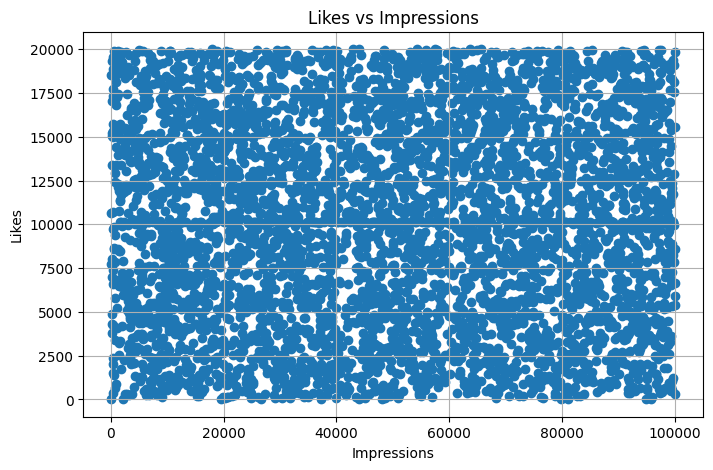

In [86]:
# ❖	Task 6 — Data Visualization
""" Matplotlib """
# 1 - Scatter Plot — Likes vs Impressions

plt.figure(figsize=(8, 5))
plt.scatter(df["impression_count"], df["likes"])
plt.xlabel("Impressions")
plt.ylabel("Likes")
plt.title("Likes vs Impressions")
plt.grid(True)
plt.show()

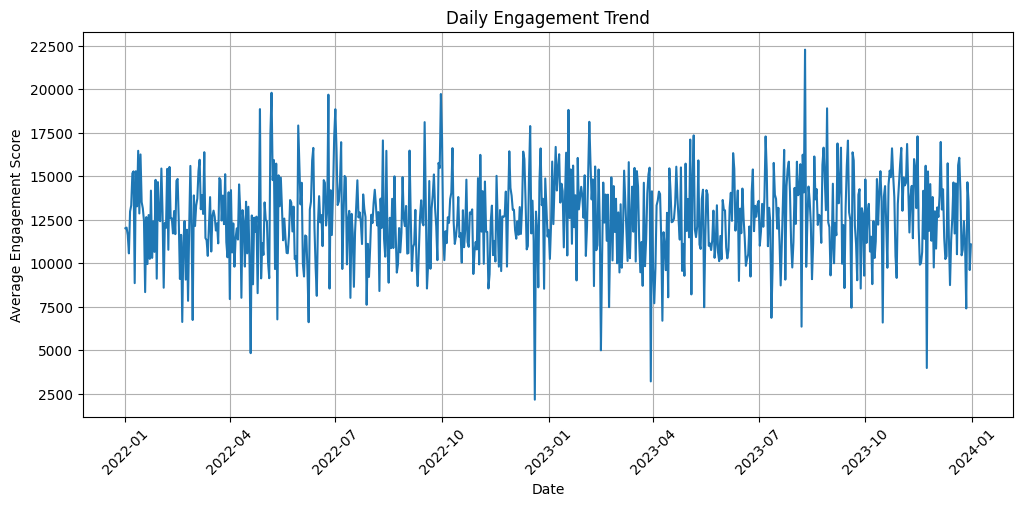

In [89]:
# 2 - Line Chart — Daily Engagement Trend

df["date"] = df["posted_at"].dt.date
daily_engagement = df.groupby("date")["engagement_score"].mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_engagement.index, daily_engagement.values)
plt.xlabel("Date")
plt.ylabel("Average Engagement Score")
plt.title("Daily Engagement Trend")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

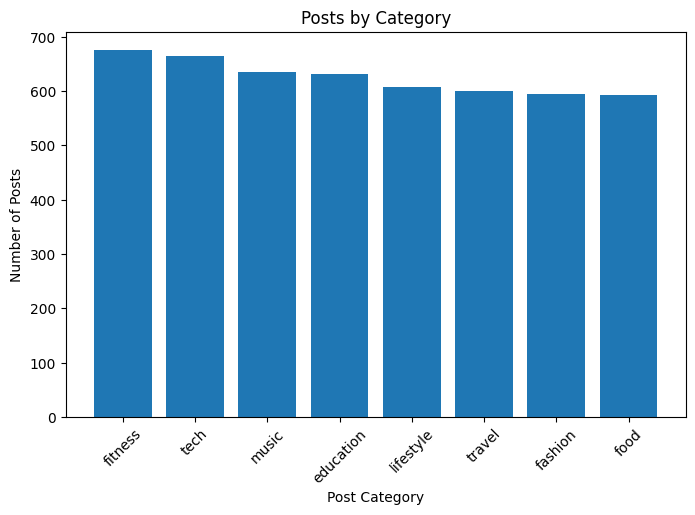

In [91]:
# 3 - Bar Chart — Posts by Category

category_counts = df["post_category"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(category_counts.index, category_counts.values)
plt.xlabel("Post Category")
plt.ylabel("Number of Posts")
plt.title("Posts by Category")
plt.xticks(rotation=45)
plt.show()

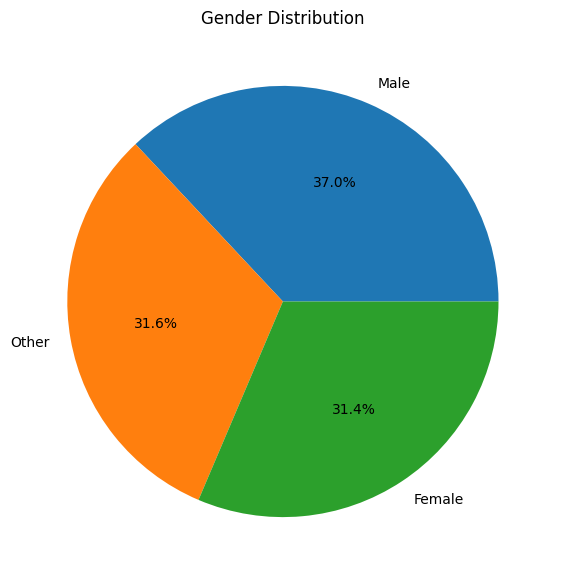

In [92]:
# 4 - Pie Chart — Gender Distribution

gender_counts = df["gender"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)
plt.title("Gender Distribution")
plt.show()

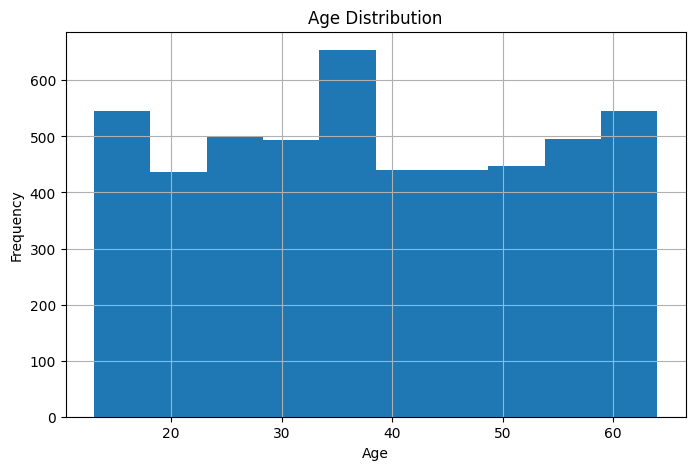

In [93]:
# 5 - Histogram — Age

plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=10)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.grid(True)
plt.show()

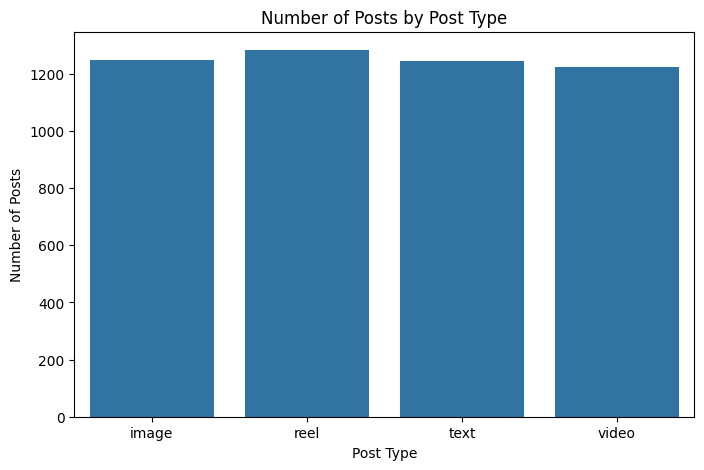

In [94]:
""" Seaborn """

# 1 - Count Plot — Post Type

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="post_type")
plt.xlabel("Post Type")
plt.ylabel("Number of Posts")
plt.title("Number of Posts by Post Type")
plt.show()

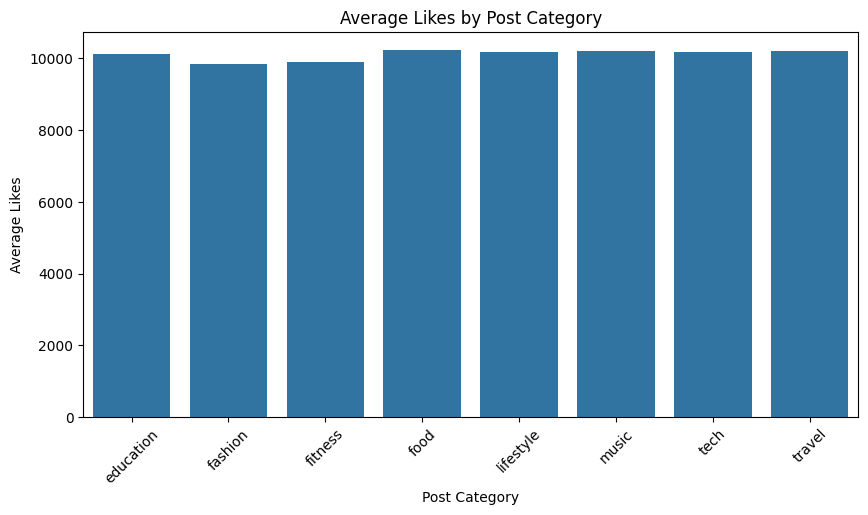

In [96]:
# 2 - Bar Plot — Average Likes by Category

avg_likes_category = (
    df.groupby("post_category")["likes"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=avg_likes_category,
    x="post_category",
    y="likes"
)
plt.xlabel("Post Category")
plt.ylabel("Average Likes")
plt.title("Average Likes by Post Category")
plt.xticks(rotation=45)
plt.show()

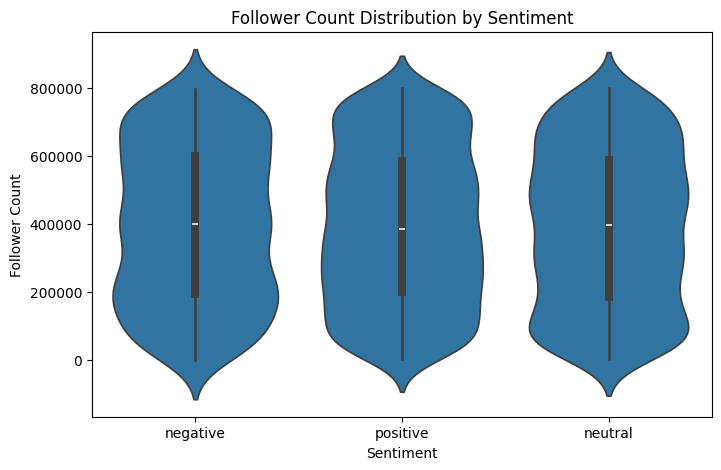

In [97]:
# 3 - Violin Plot — Followers vs Sentiment

plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df,
    x="sentiment",
    y="follower_count"
)
plt.xlabel("Sentiment")
plt.ylabel("Follower Count")
plt.title("Follower Count Distribution by Sentiment")
plt.show()

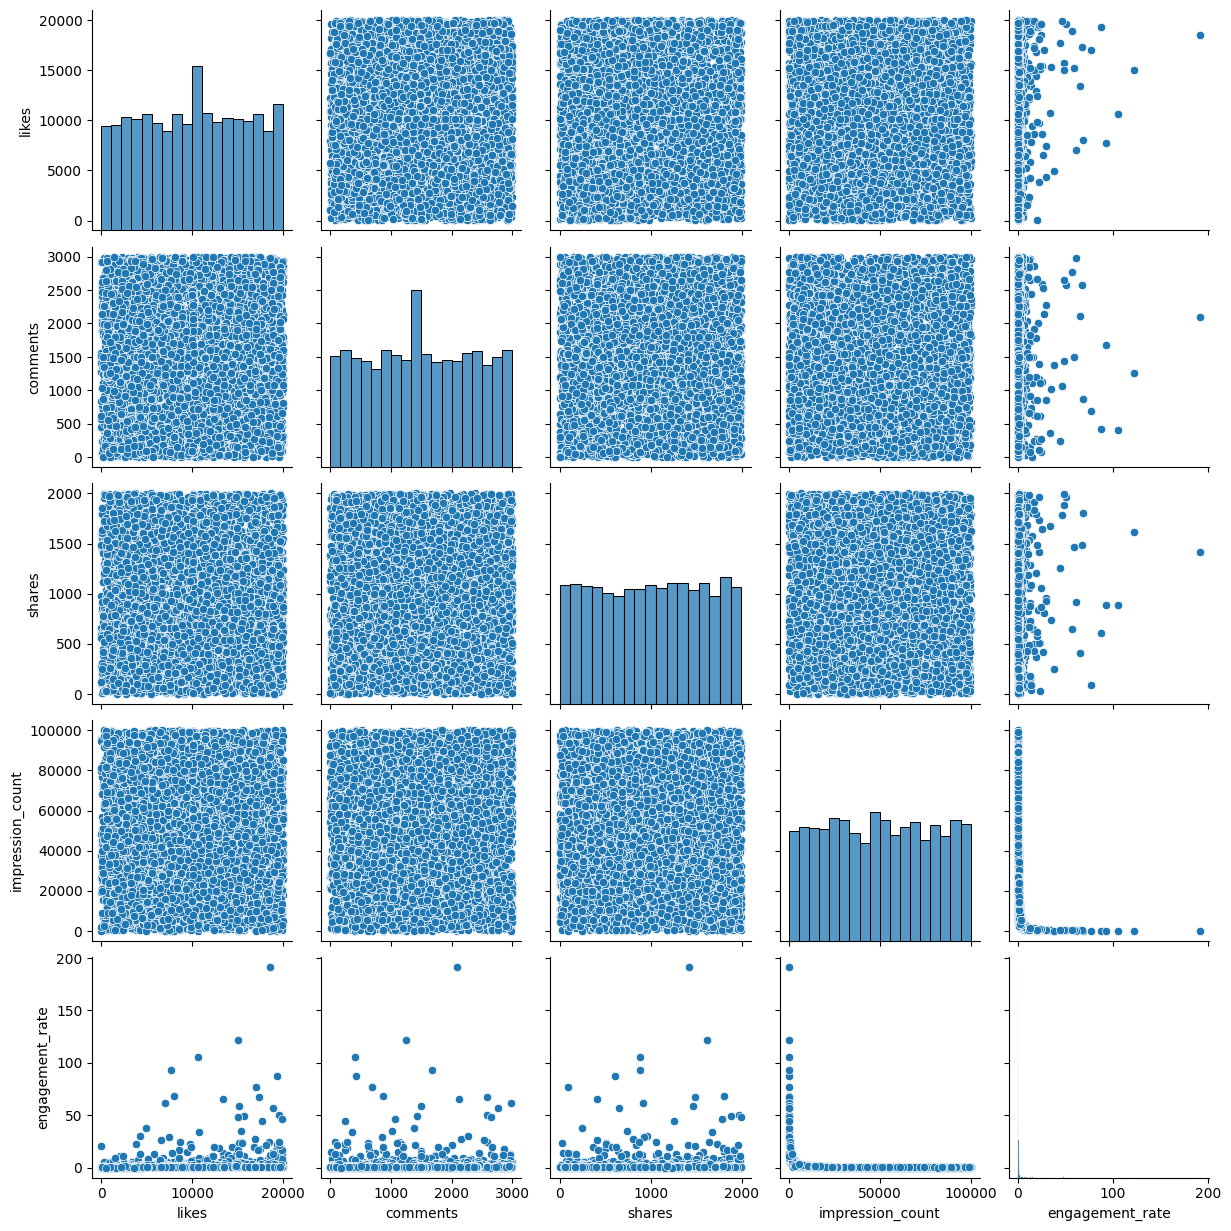

In [98]:
# 4 - Pair Plot — Numeric Features

pair_data = df[
    [
        "likes",
        "comments",
        "shares",
        "impression_count",
        "engagement_rate"
    ]
]
sns.pairplot(pair_data)
plt.show()  # - used smaller selection here due to 5000 rows in dataframe

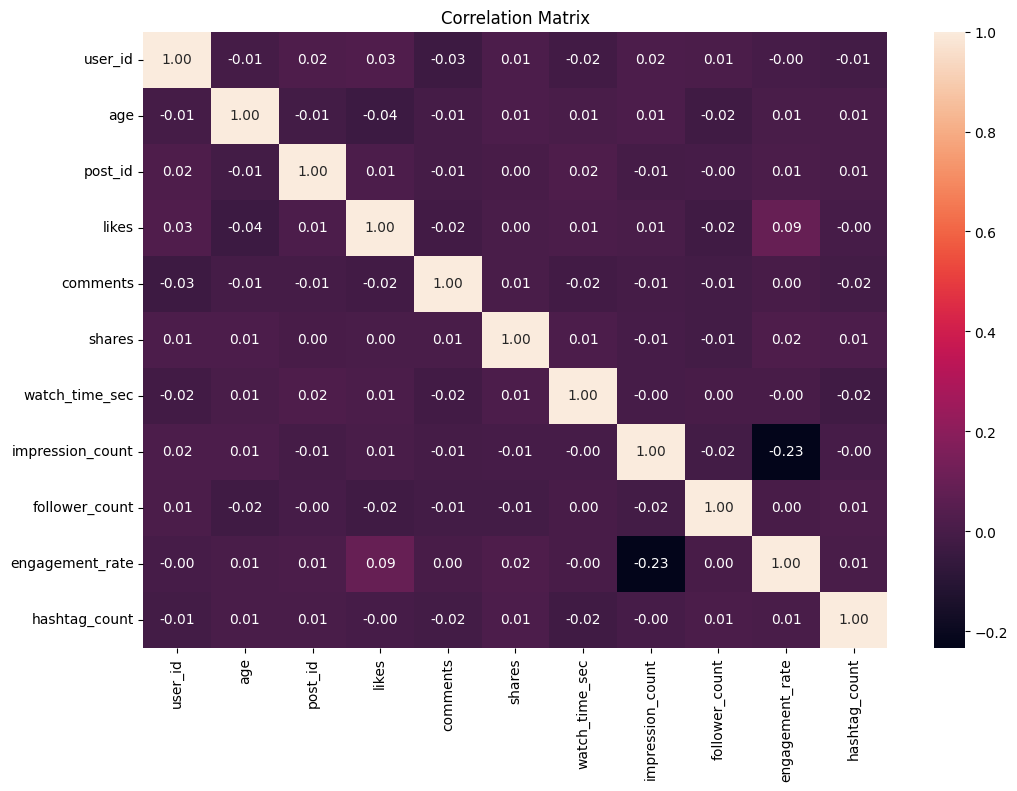

In [99]:
# 5 - Heatmap — Correlation Matrix

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

In [101]:
""" Plotly Interactive Chart"""

daily_engagement = (
    df.groupby("date")["engagement_score"]
    .mean()
    .reset_index()
)

fig = px.line(
    daily_engagement,
    x="date",
    y="engagement_score",
    title="Interactive Daily Engagement Trend",
    labels={
        "date": "Date",
        "engagement_score": "Average Engagement Score"
    }
)
fig.show()